# Example code for connecting a Sciospec device

## EIT device

**USB-HS**

If you have issues with the connection try [this](https://eblot.github.io/pyftdi/installation.html).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sciopy import EIT_16_32_64_128, EitMeasurementSetup

In [2]:
# create a 'sciospec' class which represents the sciospec EIT device
n_el = 32
sciospec = EIT_16_32_64_128(n_el)

In [3]:
# connect device via USB-HS port
sciospec.connect_device_HS()

In [4]:
# read system message buffer
sciospec.SystemMessageCallback()
# should be empty

No message inside the message buffer
message buffer:
 ['0x18', '0x1', '0x4', '0x18', '0x18', '0x1', '0x84', '0x18']
message length:	 8


In [5]:
# get device info
sciospec.GetDeviceInfo()

Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0xd1', '0x14', '0x1', '0x0', '0x19', '0x2', '0x65', '0x10', '0x3', '0x3', '0x0', '0x21', '0x0', '0x8d', '0x0', '0xba', '0x0', '0xe4', '0x0', '0xba', '0x0', '0xe4', '0xd1', '0x18', '0x1', '0x83', '0x18']
message length:	 27


In [30]:
# create a measurement setup
setup = EitMeasurementSetup(
    burst_count=1,
    n_el=n_el,
    exc_freq=1_000,
    framerate=3,
    amplitude=0.01,
    inj_skip=0,
    gain=1,
    adc_range=5,
)

In [31]:
sciospec.SetMeasurementSetup(setup)

Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0x18', '0x1', '0x83', '0x18']
message length:	 4
Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0x18', '0x1', '0x83', '0x18']
message length:	 4
Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0x18', '0x1', '0x83', '0x18']
message length:	 4
Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0x18', '0x1', '0x83', '0x18']
message length:	 4


In [32]:
# look inside the docstring of the function and manual
sciospec.GetMeasurementSetup(2)

TBD (to be checked)
Command-Acknowledge: Command has been executed successfully
message buffer:
 ['0xb1', '0x3', '0x2', '0x0', '0x1', '0xb1', '0x18', '0x1', '0x83', '0x18']
message length:	 10
TBD: Translation


In [33]:
#sciospec.update_BurstCount(4)

In [34]:
# get data
data_0 = sciospec.StartStopMeasurement(return_as="pot_mat")  # or "hex"
# data.shape = (burst_count, n_el, n_el)
# check if data shape equals setup
assert data_0.shape[0] == setup.burst_count

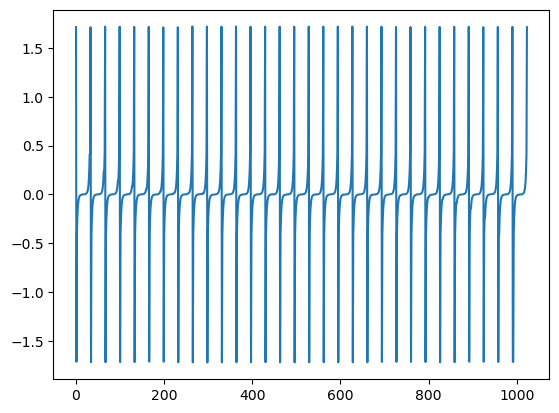

In [37]:
for pot in data_0:
    plt.plot(np.real(pot.flatten()))

Change something on the phantom

In [43]:
# get data
data_1 = sciospec.StartStopMeasurement(return_as="pot_mat")  # or "hex"
# data.shape = (burst_count, n_el, n_el)
# check if data shape equals setup
assert data_1.shape[0] == setup.burst_count

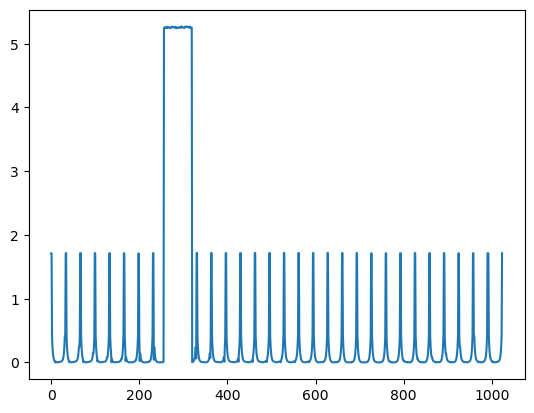

In [44]:
for pot in data_1:
    plt.plot(np.abs(pot.flatten()))

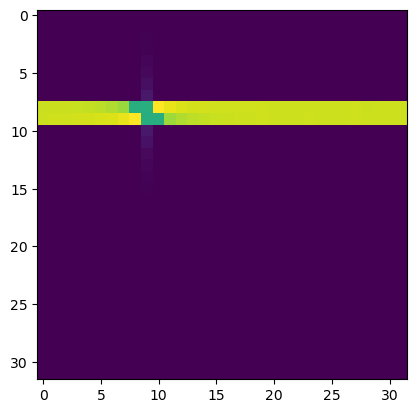

In [40]:
data = data_1-data_0
for pot in data:
    plt.imshow(np.abs(pot))
    plt.show()

In [15]:
d0 = np.diff(data_0.flatten(), append=data_0.flatten()[-1])

In [16]:
d1 = np.diff(data_1.flatten(), append=data_1.flatten()[-1])

(0.0, 35.0)

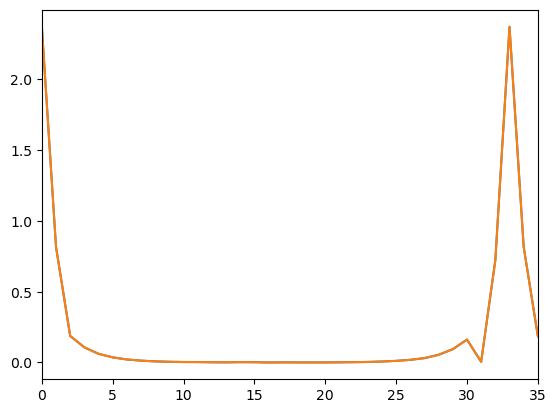

In [17]:
plt.plot(np.abs(d0))
plt.plot(np.abs(d1))
plt.xlim([0,35])

In [18]:
abs(data[0,1,:])

array([1.99374064e-04, 4.57524450e-04, 4.32687240e-04, 1.24907308e-04,
       6.33593869e-05, 4.56193763e-05, 4.75973902e-05, 5.54942255e-05,
       5.74022984e-05, 5.52140546e-05, 6.66276446e-05, 6.13030226e-05,
       6.02718391e-05, 6.69965106e-05, 6.11999090e-05, 6.76837959e-05,
       6.11215231e-05, 6.26887322e-05, 6.25784182e-05, 6.09588752e-05,
       6.45932617e-05, 6.03679218e-05, 6.35512850e-05, 6.24106123e-05,
       6.16357695e-05, 7.33561331e-05, 6.06342353e-05, 7.11609493e-05,
       7.34195697e-05, 7.50249677e-05, 9.92650223e-05, 1.28357489e-04])

In [19]:
abs(data[0,2,:])

array([1.02363030e-04, 1.46313849e-04, 3.11154612e-04, 2.78583974e-04,
       8.09806018e-05, 3.68793542e-05, 2.63866548e-05, 2.65659120e-05,
       3.36026736e-05, 3.41811469e-05, 2.98064237e-05, 3.58745262e-05,
       3.01800618e-05, 3.89231851e-05, 3.18832099e-05, 3.74617245e-05,
       3.47063111e-05, 4.39307486e-05, 3.74252928e-05, 3.30476321e-05,
       4.23797958e-05, 4.32881682e-05, 3.41088402e-05, 3.81523427e-05,
       3.94577691e-05, 3.87632164e-05, 3.99456672e-05, 4.02552912e-05,
       4.69936571e-05, 4.14156458e-05, 4.99788884e-05, 5.93829145e-05])

In [20]:
np.abs(data.flatten()[:16])

array([0.00095033, 0.00089374, 0.00028051, 0.00016192, 0.00013652,
       0.00013013, 0.00013085, 0.00013495, 0.0001451 , 0.00015001,
       0.00014344, 0.00014393, 0.00014325, 0.00014962, 0.0001415 ,
       0.00014056])